<a href="https://colab.research.google.com/github/yohanesnuwara/GeoPySics/blob/master/NorthernLights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 20

!pip install bruges
from bruges.petrophysics import *
from bruges.rockphysics import *

In [ ]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
eos = pd.read_csv('https://raw.githubusercontent.com/yohanesnuwara/formation-evaluation/main/data/northernlights/Eos_31_5_7_Combined.csv')
eos['VP'] = 1E+06 / eos.DT * 0.3048
eos['VS'] = 1E+06 / eos.DTS * 0.3048


eos.head()

,DEPTH,CALI,DRHO,DT,DTS,GR,KTIM,NPHI,PPC1_CALI_NORM,RD,RHOB,RM,RS,RT,RXO,TVDMSL,CARB_FLAG,COAL_FLAG,KLOGH,PHIT,SAND_FLAG,VSH,FM. LABEL,VP,VS
0,1892.3508,NaN,NaN,133.0340,NaN,163.4759,NaN,NaN,12.2390,1.7355,NaN,1.5018,1.4094,1.5766,NaN,1861.2841,NaN,NaN,NaN,NaN,0.0,0.6956,Draupne,2291.143617,NaN
1,1892.5032,NaN,NaN,143.3587,NaN,169.1015,NaN,NaN,12.2415,1.6592,NaN,1.6291,1.6041,1.6848,NaN,1861.4365,NaN,NaN,NaN,NaN,0.0,0.7425,Draupne,2126.135351,NaN
2,1892.6556,NaN,NaN,138.2003,NaN,192.5121,NaN,NaN,12.2484,1.6274,NaN,1.3411,1.3574,1.3609,NaN,1861.5889,NaN,NaN,NaN,NaN,0.0,0.9376,Draupne,2205.494489,NaN
3,1892.8080,NaN,NaN,132.8561,NaN,221.3074,NaN,NaN,12.2499,1.5528,NaN,1.2150,1.2409,1.2092,NaN,1861.7413,NaN,NaN,NaN,NaN,0.0,1.1776,Draupne,2294.211557,NaN
4,1892.9604,NaN,NaN,130.3214,NaN,240.5081,NaN,NaN,12.2450,1.4950,NaN,1.1425,1.1469,1.1238,NaN,1861.8937,NaN,NaN,NaN,NaN,0.0,1.3376,Draupne,2338.833070,NaN


In [ ]:
import plotly.express as px

df = eos[eos['FM. LABEL'].str.contains('Johansen')]
# df = eos
fig = px.scatter(df, x='VS', y='VP', color='FM. LABEL')
fig.show()

In [ ]:
def voigt(volume_frac, param):
    return np.sum(np.array(volume_frac) * np.array(param))

def reuss(volume_frac, param):
    return 1 / np.sum(np.array(volume_frac) * (1/np.array(param)))

def green_castag(min, f, Vp):
  """
  Estimate Vs from Vp using Greenberg-Castagna (1992)
  """
  poly_coef = {'qtz': [0, 0.80416, -0.85588],
               'cly': [0, 0.76969, -0.86735],
               'lst': [-0.05508, 1.01677, -1.03049],
               'dol': [0, 0.58321, -0.07775],
               'toc': [0, 0.571, 0]}
  Z = []
  for i in min:
    a = poly_coef[i]
    lith_Vs = a[0]*Vp**2 + a[1]*Vp + a[2]
    Z.append(lith_Vs)

  v = voigt(f, Z)
  r = reuss(f, Z)
  return 0.5 * (v + r)

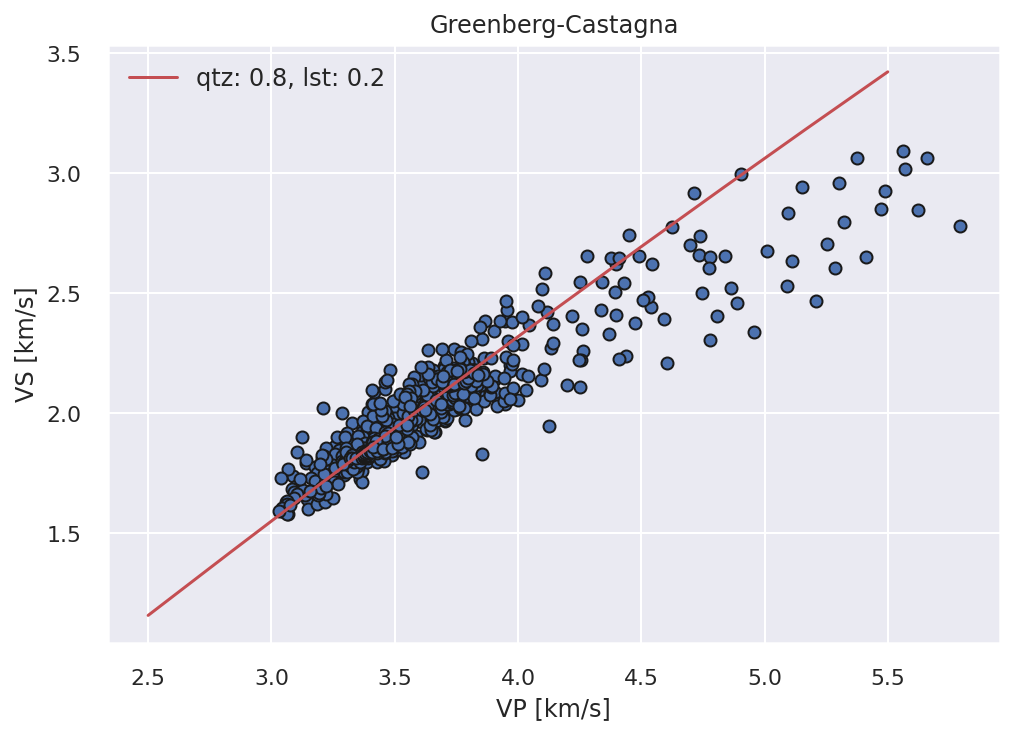

In [ ]:
df = eos[eos['FM. LABEL'].str.contains('Johansen')]

# Estimate Vs from Vp list
min = ['qtz', 'lst']
f = [0.8, 0.2]

vp = np.linspace(2.5, 5.5, 10)
vs = [green_castag(min, f, i) for i in vp]

plt.plot(vp, vs, c='r', label=f'{min[0]}: {f[0]}, {min[1]}: {f[1]}')
plt.scatter(df.VP*1e-3, df.VS*1e-3, lw=1, edgecolor='k')
plt.xlabel('VP [km/s]'); plt.ylabel('VS [km/s]')
plt.title('Greenberg-Castagna')
plt.legend(fontsize=12)
plt.show()

In [ ]:
!wget https://raw.githubusercontent.com/yohanesnuwara/formation-evaluation/main/ND_plot.py
from ND_plot import ND_plot

--2021-10-13 07:35:57--  https://raw.githubusercontent.com/yohanesnuwara/formation-evaluation/main/ND_plot.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3965 (3.9K) [text/plain]
Saving to: ‘ND_plot.py’

ND_plot.py          100%[===================>]   3.87K  --.-KB/s    in 0s      

2021-10-13 07:35:57 (48.7 MB/s) - ‘ND_plot.py’ saved [3965/3965]



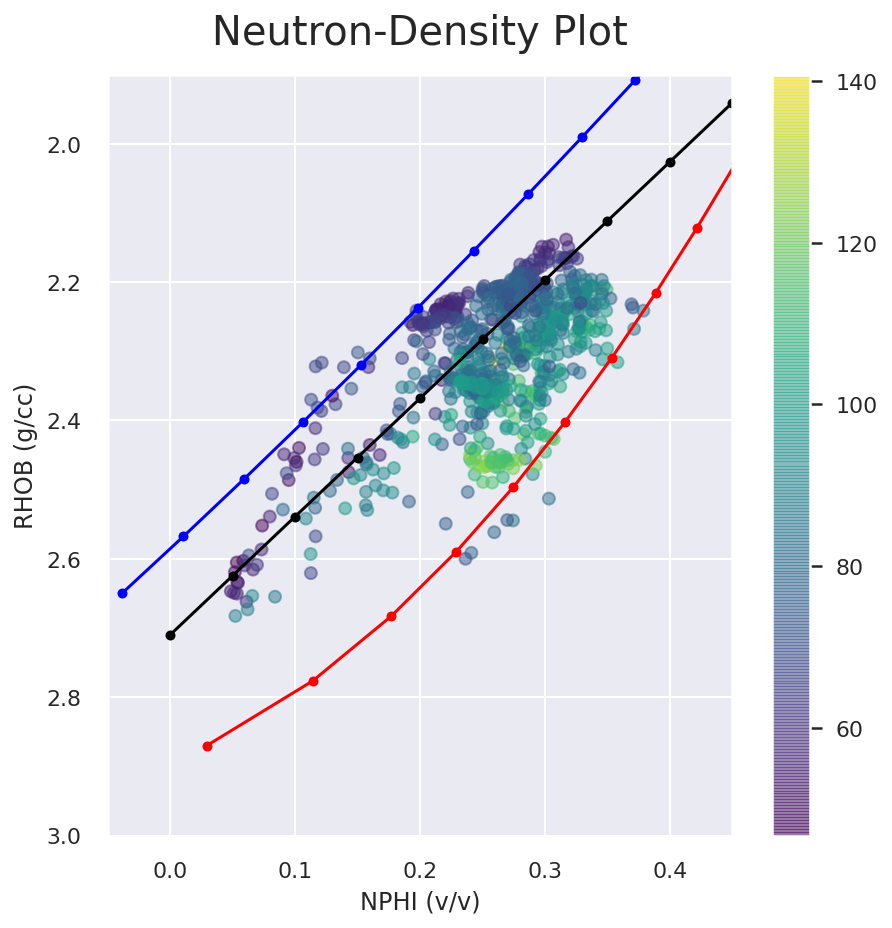

In [ ]:
ND_plot(1., df, 'NPHI', 'RHOB', 'GR', 'continuous')

Johansen Fm. shows the evidence of increasing cementation from shallow to deeper depth. The blue points may be classified as friable sand, the lighter points may be cemented sand.

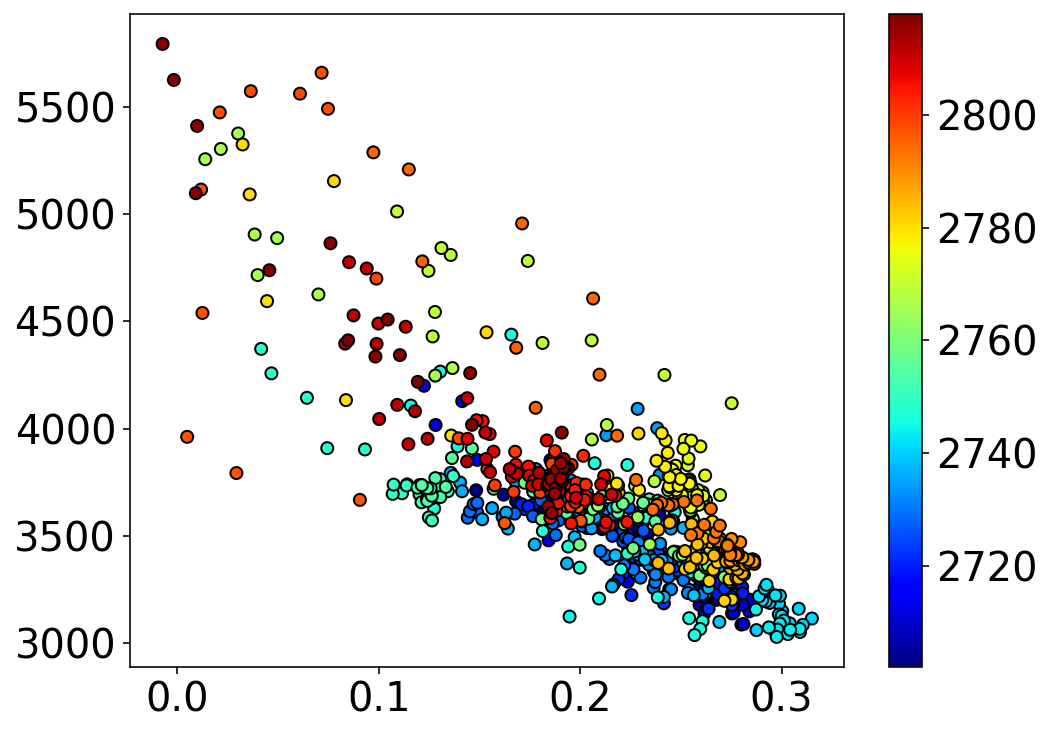

In [ ]:
df = eos[eos['FM. LABEL'].str.contains('Johansen')]

plt.figure(figsize=(8,6))
plt.scatter(df.PHIT, df.VP, c=df.DEPTH, lw=1, edgecolor='black', cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
def vrh(volumes,k,mu):
    '''
    Calculates Voigt-Reuss-Hill bounds, (C) aadm 2015

    INPUT
    volumes: array with volumetric fractions
    k: array with bulk modulus
    mu: array with shear modulus

    OUTPUT
    k_u, k_l: upper (Voigt) and lower (Reuss) average of k
    mu_u, mu_l: upper (Voigt) and lower (Reuss) average of mu
    k0, mu0: Hill average of k and mu
    '''
    f=np.array(volumes).T
    k=np.resize(np.array(k),np.shape(f))
    mu=np.resize(np.array(mu),np.shape(f))
    ax=0 if f.ndim==1 else 1
    k_u = np.sum(f*k,axis=ax)
    k_l = 1./np.sum(f/k,axis=ax)
    mu_u = np.sum(f*mu,axis=ax)
    mu_l = 1./np.sum(f/mu,axis=ax)
    k0 = (k_u+k_l)/2.
    mu0 = (mu_u+mu_l)/2.
    return k_u, k_l, mu_u, mu_l, k0, mu0

In [ ]:
def vels(Kd, Gd, D0):
  rho = D0 * (1 - phi)
  Vp = np.sqrt((Kd + 4 / 3 * Gd) / rho)
  Vs = np.sqrt(Gd / rho)
  return Vp, Vs

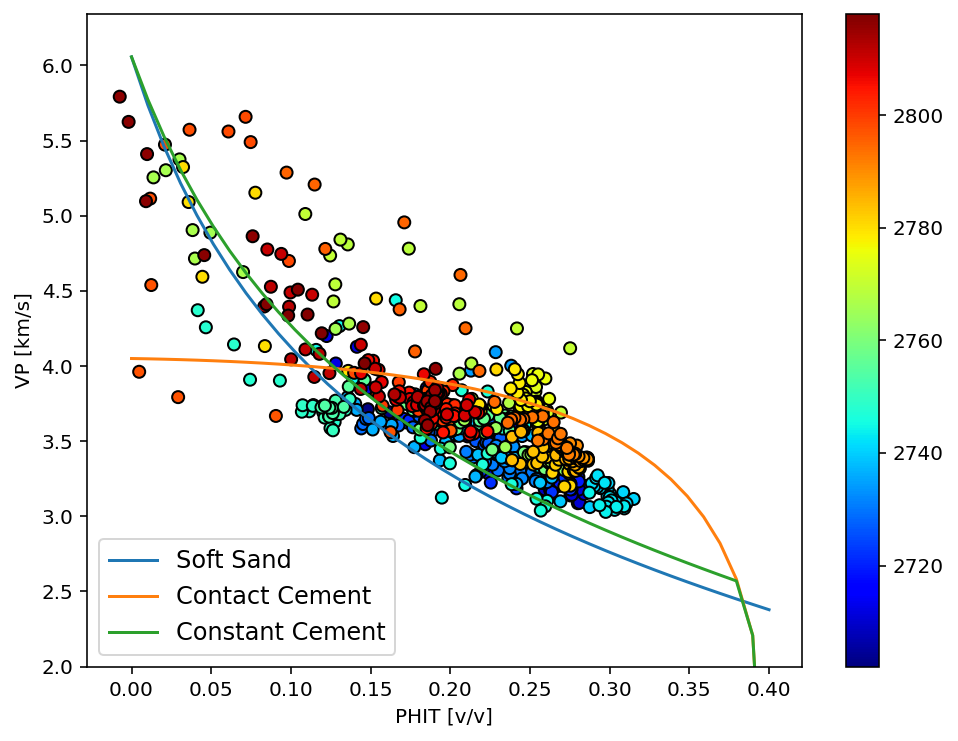

In [ ]:
# GRAIN
vcl = 0.2
Kcl, Kqtz = 73, 37 # 15
Gcl, Gqtz = 32, 44 # 5
Dcl, Dqtz = 2.71, 2.65

# Voigt Reuss bounds
Kv, Kr, Gv, Gr, K0, G0 = vrh([vcl, 1-vcl], [Kcl, Kqtz], [Gcl, Gqtz])

D0 = vcl*Dcl + (1-vcl)*Dqtz
phi = np.linspace(0, 0.4, 40)
phi_c = 0.4
sigma = 80
Cn = 9
Kc, Gc = 73, 32
f = 1
scheme = 2

# Constant cement line
Kd_cons, Gd_cons = constant_cement(K0, G0, phi, phi_c=phi_c, Cn=Cn,
                                   Kc=Kc, Gc=Gc, scheme=scheme)
Vp_cons, Vs_cons = vels(Kd_cons, Gd_cons, D0)

# Soft sand (modified lower HS bound)
Kd_soft, Gd_soft = soft_sand(K0, G0, phi, sigma=80, phi_c=phi_c, Cn=Cn, f=f)
Vp_soft, Vs_soft = vels(Kd_soft, Gd_soft, D0)

# Cemented sand model (contact cement model)
Kd_cont, Gd_cont = contact_cement(K0, G0, phi, phi_c=phi_c, Cn=Cn,
                                  Kc=Kc, Gc=Gc, scheme=scheme)
Vp_cont, Vs_cont = vels(Kd_cont, Gd_cont, D0)

cmap = plt.cm.get_cmap('jet', 10)

plt.figure(figsize=(8,6))
plt.plot(phi, Vp_soft, label='Soft Sand')
plt.plot(phi, Vp_cont, label='Contact Cement')
plt.plot(phi, Vp_cons, label='Constant Cement')

df = eos[eos['FM. LABEL'].str.contains('Johansen')]
plt.scatter(df.PHIT, df.VP*1e-3, c=df.DEPTH, lw=1, edgecolor='black', cmap='jet')
plt.colorbar()

plt.ylim(ymin=2)
plt.xlabel('PHIT [v/v]')
plt.ylabel('VP [km/s]')
# plt.title('Johansen Fm.')
plt.legend(fontsize=12, loc='lower left')
plt.show()

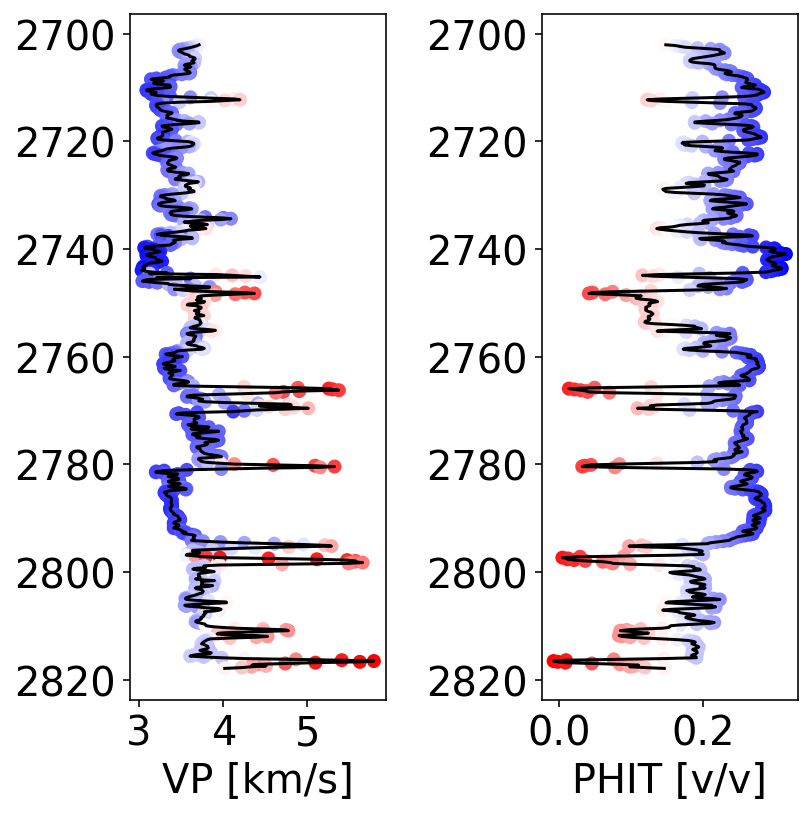

In [ ]:
df = eos[eos['FM. LABEL'].str.contains('Johansen')]

plt.figure(figsize=(6,6))

plt.subplot(1,2,1)
plt.plot(df.VP*1e-3, df.DEPTH, c='k')
plt.scatter(df.VP*1e-3, df.DEPTH, c=df.RHOB, cmap='bwr')
plt.xlabel('VP [km/s]')
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.plot(df.PHIT, df.DEPTH, c='k')
plt.scatter(df.PHIT, df.DEPTH, c=df.RHOB, cmap='bwr')
plt.xlabel('PHIT [v/v]')
plt.gca().invert_yaxis()

plt.tight_layout(1.)

(array([202., 122., 503.,   6.,   1.,   1.,   3.,   0.,   0.,   2.]),
 array([0.053104 , 0.0826197, 0.1121354, 0.1416511, 0.1711668, 0.2006825,
        0.2301982, 0.2597139, 0.2892296, 0.3187453, 0.348261 ]),
 <a list of 10 Patch objects>)

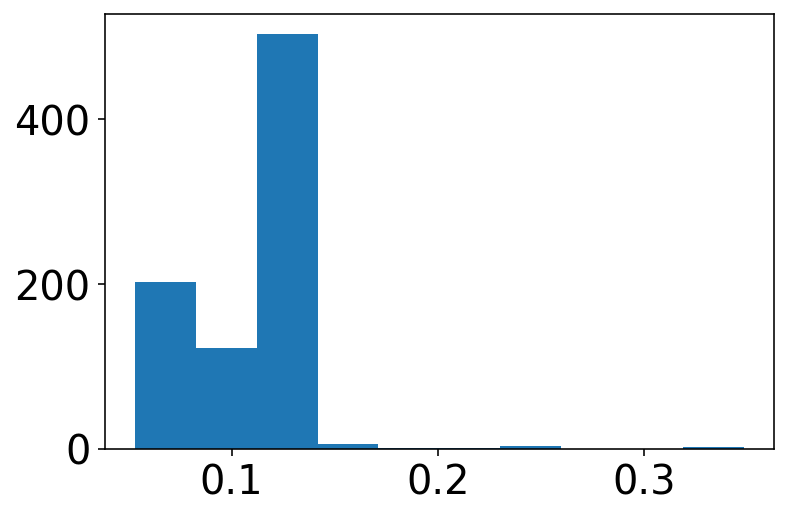

In [ ]:
df = eos[eos['FM. LABEL'].str.contains('Drake')]

plt.hist(df.PHIT)

(array([ 10.,  12.,  13.,  33.,  61.,  77., 141., 150., 220.,  44.]),
 array([-0.007387 ,  0.0248575,  0.057102 ,  0.0893465,  0.121591 ,
         0.1538355,  0.18608  ,  0.2183245,  0.250569 ,  0.2828135,
         0.315058 ]),
 <a list of 10 Patch objects>)

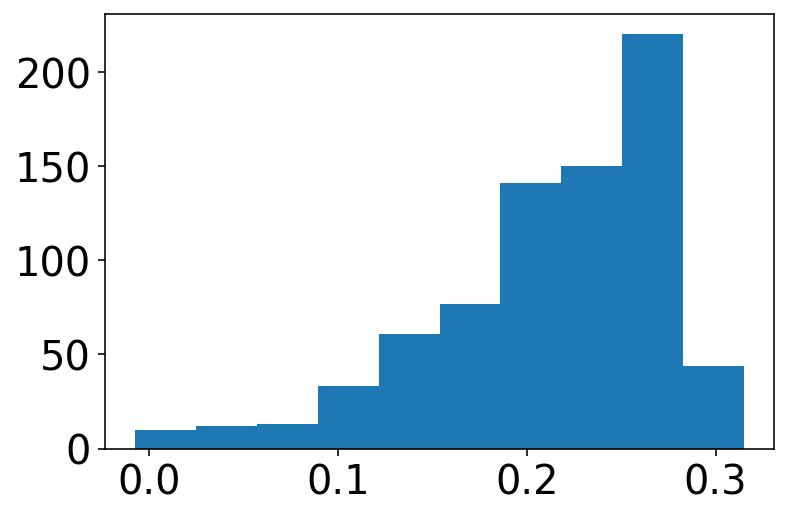

In [ ]:
df = eos[eos['FM. LABEL'].str.contains('Johansen')]

plt.hist(df.PHIT)

In [ ]:
def thomas_stieber(vsh, rhob, rho_clean_sand, rho_shale,
                   phi_clean_sand, phi_shale, rho_water=1, c=None):
  """
  Thomas-Stieber model for sand-shale system
  """

  # Three points
  ## Point A. Clean sand point
  # plt.scatter(0, rho_clean_sand, c='r')
  # plt.text(0, rho_clean_sand - 0.05, 'Clean Sand')

  ## Point C. Shale point
  # plt.scatter(1, rho_shale, c='r')

  ## Point B. Sand with pore space completely filled with shale point
  rho_disp = rho_clean_sand + phi_clean_sand * (rho_shale - rho_water)
  vsh_disp = phi_clean_sand
  # plt.scatter(vsh_disp, rho_disp, c='r')
  # plt.text(vsh_disp - 0.08, rho_disp + 0.02, 'Pore-filled w/ shale')

  # Lines
  ## Line AB. Dispersed shale
  plt.plot([0, vsh_disp], [rho_clean_sand, rho_disp], color='k',
           label='Sand with Dispersed Shale')

  ## Line BC. Shale with Dispersed Quartz
  plt.plot([vsh_disp, 1], [rho_disp, rho_shale], color='k',
           label='Shale with Dispersed Quartz')

  ## Line AC.
  plt.plot([0, 1], [rho_clean_sand, rho_shale], color='k')

  # V dispersed shale lines
  ## divide line AB into 6 points (0, .2, .4, .6, .8, 1)
  vsh_disp_point = np.linspace(0, vsh_disp, 6)
  rho_disp_point = np.linspace(rho_clean_sand, rho_disp, 6)

  ## Plot multiple lines
  [plt.plot([i0, i1], [j0, j1], color='black') for i0, i1, j0, j1 in \
   zip(vsh_disp_point[1:-1], np.full(4, 1),
       rho_disp_point[1:-1], np.full(4, rho_shale))]

  text = ['$0.2 \phi$', '$0.4 \phi$', '$0.6 \phi$', '$0.8 \phi$']
  opt1={'backgroundcolor':'0.9'}
  [plt.text(i, j, k, size=12, **opt1) for i, j, k in zip(vsh_disp_point[1:-1]-0.07,
                                        rho_disp_point[1:-1], text)]

  # NTG lines
  ## divide line BC into 6 points (0, .2, .4, .6, .8, 1)
  vsh_ntg_point1 = np.linspace(vsh_disp, 1, 6)
  rho_ntg_point1 = np.linspace(rho_disp, rho_shale, 6)

  ## divide line AC into 6 points (0, .2, .4, .6, .8, 1)
  vsh_ntg_point2 = np.linspace(0, 1, 6)
  rho_ntg_point2 = np.linspace(rho_clean_sand, rho_shale, 6)

  ## Plot multiple lines
  [plt.plot([i0, i1], [j0, j1], color='black') for i0, i1, j0, j1 in \
   zip(vsh_ntg_point1[1:-1], vsh_ntg_point2[1:-1],
       rho_ntg_point1[1:-1], rho_ntg_point2[1:-1])]

  text = ['$N/G=0.2$', '$N/G=0.4$', '$N/G=0.6$', '$N/G=0.8$']
  [plt.text(i, j, k, size=12, **opt1) for i, j, k in zip(vsh_ntg_point2[1:-1]-0.04,
                                        rho_ntg_point2[1:-1]-0.04, text)]

  # Data points
  plt.scatter(vsh, rhob, c=c, lw=1, edgecolor='k', cmap='jet')
  plt.colorbar()

  # plt.xlim(0, 1); plt.ylim(1.95, 2.95)
  plt.xlabel('VCL [v/v]'); plt.ylabel('RHOB [g/cc]')

  # plt.title('Thomas-Stieber Model for Sand-Shale System', pad=15)
  # plt.legend(prop={'size': 10})
  # plt.grid()
  # plt.show()

(2.1, 2.7)

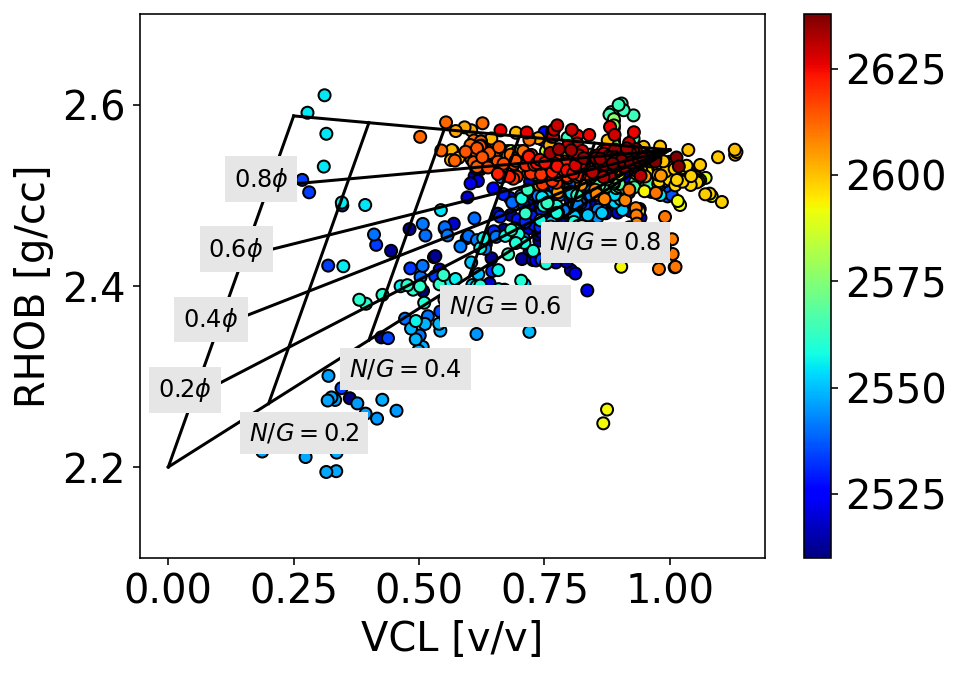

In [ ]:
plt.figure(figsize=(7,5))

df = eos[eos['FM. LABEL'].str.contains('Drake')]
cutof_clean, cutof_shale = 75, 160
vcl = (df.GR - cutof_clean) / (cutof_shale - cutof_clean)
rhob = df.RHOB
depth = df.DEPTH

thomas_stieber(vcl, rhob, 2.2, 2.55, 0.25, 0.12, c=depth)
plt.ylim(2.1,2.7)